# VGGT Hands-On SPCOM Tutorial
## Instructor : Dr. Lokender Tiwari

**VGGT** is a single **feed-forward** transformer that takes one, a few, or hundreds of images and predicts *all* of the following **in one forward pass, in under a second** — no per-scene optimization, no bundle adjustment, no iterative global alignment like DUSt3R/MASt3R require:

1. **Camera extrinsics & intrinsics** for every input image
2. **Dense depth maps** (+ confidence) per image
3. **Dense 3D point maps** (+ confidence) per image, directly in world coordinates
4. **2D point tracks** across all images for arbitrary query points

This notebook walks through the following end-to-end tasks :
1. A single forward pass over a multi-image scene
2. Visualizing every intermediate/output head separately: camera poses, depth, confidence, point maps, tracks
3. Comparing the two ways VGGT gives you 3D points (point-map branch vs. depth+camera unprojection)
4. An interactive 3D viewer of the reconstruction
5. Export to `.ply`

**Before running:** `Runtime → Change runtime type → T4 GPU`.


## Step 0.  Confirm we have a GPU

In [1]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("Compute capability:", torch.cuda.get_device_capability() if torch.cuda.is_available() else None)


Tue Jul 14 20:23:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1. Clone VGGT and install dependencies

Unlike DUSt3R/MASt3R, VGGT needs no CUDA-kernel compilation step — it's pure PyTorch (torch, torchvision, numpy, Pillow, huggingface_hub).


In [2]:
%cd /content
!git clone https://github.com/facebookresearch/vggt --quiet
%cd /content/vggt

!grep -v -iE '^(numpy|torch(vision|audio)?)([=<>~!].*)?$' requirements.txt > requirements_colab.txt
!pip install -q -r requirements_colab.txt
# Extra libs used later in this notebook for visualization / export
!pip install -q plotly trimesh
print("Dependencies installed.")


/content
/content/vggt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 25.2 MB/s eta 0:00:00
Dependencies installed.


## Step 2. Load the pretrained model

`VGGT.from_pretrained("facebook/VGGT-1B")` downloads the weights from Hugging Face the first time it's run (may take a few minutes). We also pick the right autocast dtype: T4 is a Turing-generation GPU (compute capability 7.5), so it does **not** get hardware-accelerated bfloat16 — we use float16 instead.


In [3]:
import sys
sys.path.insert(0, '/content/vggt')

import torch
from vggt.models.vggt import VGGT

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8) else torch.float16
print("Using dtype:", dtype)

model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)
model.eval()
print("VGGT loaded on", device)


Using dtype: torch.float16


config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

VGGT loaded on cuda


## Step 3. Sample images

VGGT's repo ships a small example scene at `examples/kitchen/images/`. We'll use that. Feel free to replace `image_names` with your own uploaded photos (see the commented-out upload cell) — VGGT works with anywhere from 1 to hundreds of images of the same scene/object.


Found 25 images


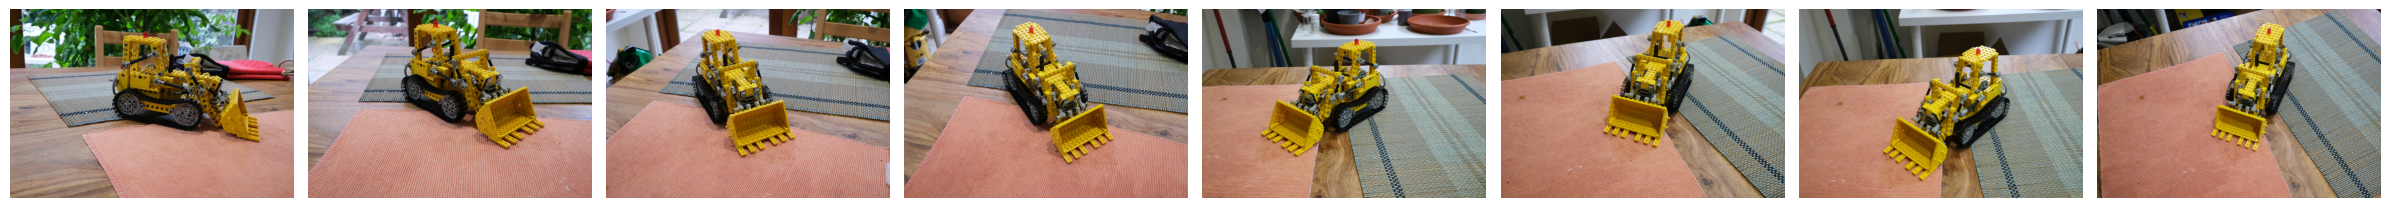

In [4]:
import glob

image_names = sorted(glob.glob('/content/vggt/examples/kitchen/images/*'))
print(f"Found {len(image_names)} images")
image_names = image_names[:8]  # keep it snappy for a T4 demo; raise this if you like

import matplotlib.pyplot as plt
from PIL import Image

n = len(image_names)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
axes = axes if n > 1 else [axes]
for ax, p in zip(axes, image_names):
    ax.imshow(Image.open(p))
    ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# Optional: uncomment to upload your own images instead
# from google.colab import files
# uploaded = files.upload()
# image_names = list(uploaded.keys())


## Step 4. Preprocess images and run a single forward pass

This is the entire "reconstruction pipeline" — one call to `model(images)`. Everything downstream in this notebook just unpacks and visualizes what comes out of it.


In [6]:
from vggt.utils.load_fn import load_and_preprocess_images

images = load_and_preprocess_images(image_names).to(device)
print("Preprocessed batch shape:", images.shape)  # (S, C, H, W)

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        predictions = model(images)

print("Prediction keys:", list(predictions.keys()))


Preprocessed batch shape: torch.Size([8, 3, 350, 518])


/tmp/ipykernel_1447/2744903383.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
/content/vggt/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Prediction keys: ['pose_enc', 'pose_enc_list', 'depth', 'depth_conf', 'world_points', 'world_points_conf', 'images']


## Step 5. Peeking at the intermediate heads individually

`model(images)` is a convenience wrapper. Under the hood VGGT runs a shared **aggregator** transformer once, then feeds its tokens to four separate, independent prediction heads. We rerun it manually here so we can inspect each stage.


In [7]:
from vggt.utils.pose_enc import pose_encoding_to_extri_intri
from vggt.utils.geometry import unproject_depth_map_to_point_map

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        images_b = images[None]  # add batch dimension -> (B=1, S, C, H, W)
        aggregated_tokens_list, ps_idx = model.aggregator(images_b)

        # --- Camera head: predicts a compact pose encoding per frame ---
        pose_enc = model.camera_head(aggregated_tokens_list)[-1]
        extrinsic, intrinsic = pose_encoding_to_extri_intri(pose_enc, images_b.shape[-2:])

        # --- Depth head: per-pixel metric depth + confidence ---
        depth_map, depth_conf = model.depth_head(aggregated_tokens_list, images_b, ps_idx)

        # --- Point head: per-pixel 3D point (in world coords) + confidence, predicted directly ---
        point_map, point_conf = model.point_head(aggregated_tokens_list, images_b, ps_idx)

# Construct 3D points by unprojecting the depth map through the predicted cameras.
# The README notes this usually gives more accurate points than the point-map branch above.
point_map_by_unprojection = unproject_depth_map_to_point_map(
    depth_map.squeeze(0), extrinsic.squeeze(0), intrinsic.squeeze(0)
)

print("extrinsic shape           :", extrinsic.shape)   # (B, S, 3, 4)
print("intrinsic shape           :", intrinsic.shape)    # (B, S, 3, 3)
print("depth_map shape           :", depth_map.shape)
print("point_map shape           :", point_map.shape)
print("point_map_by_unprojection :", point_map_by_unprojection.shape)


/tmp/ipykernel_1447/907113454.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


extrinsic shape           : torch.Size([1, 8, 3, 4])
intrinsic shape           : torch.Size([1, 8, 3, 3])
depth_map shape           : torch.Size([1, 8, 350, 518, 1])
point_map shape           : torch.Size([1, 8, 350, 518, 3])
point_map_by_unprojection : (8, 350, 518, 3)


## Step 6. Visualize per-frame depth and confidence

The confidence maps are what let VGGT automatically discard unreliable pixels — e.g. reflective surfaces, sky, thin structures — without any hand-tuned thresholding logic.


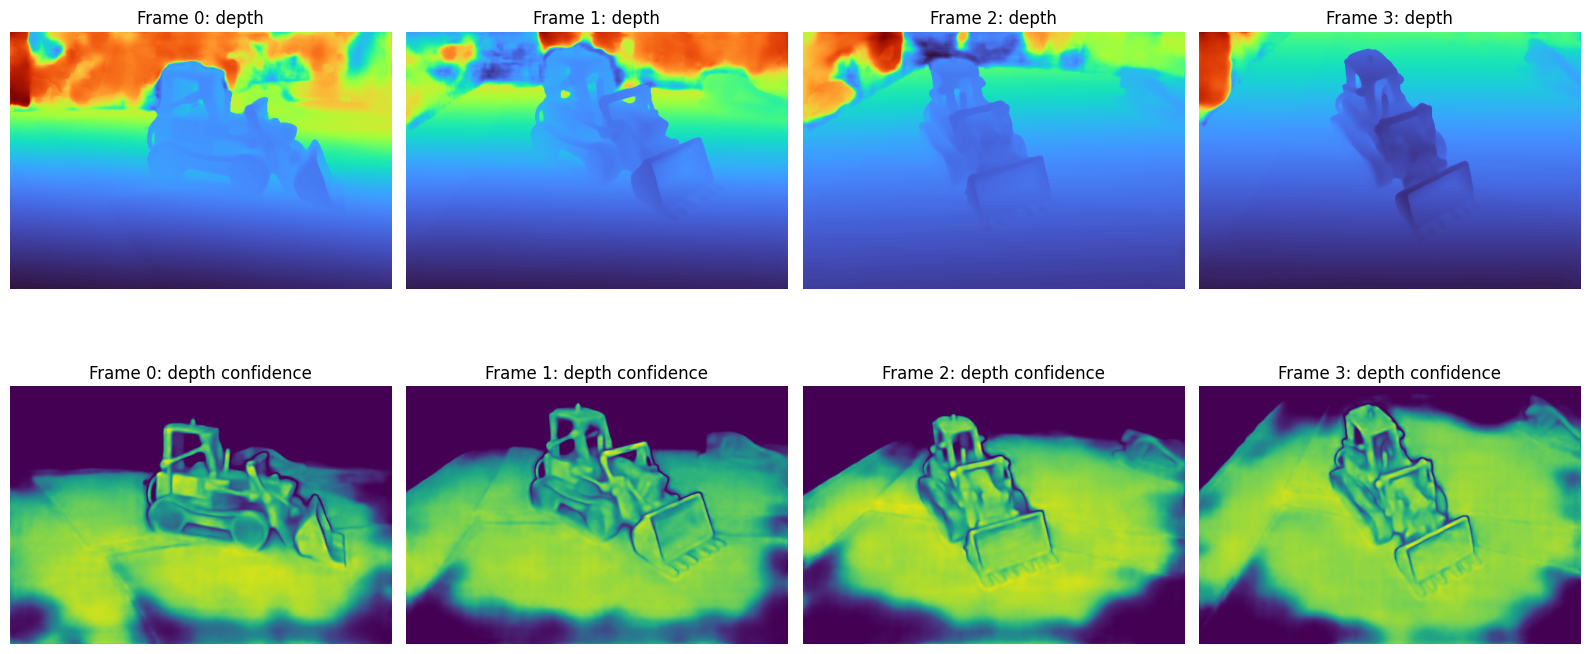

In [8]:
import numpy as np

def to_np(t):
    return t.detach().float().cpu().numpy()

depth_np = to_np(depth_map.squeeze(0)).squeeze(-1)   # (S, H, W)
dconf_np = to_np(depth_conf.squeeze(0))              # (S, H, W)

n_show = min(4, depth_np.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i in range(n_show):
    axes[0, i].imshow(depth_np[i], cmap='turbo')
    axes[0, i].set_title(f'Frame {i}: depth')
    axes[0, i].axis('off')
    axes[1, i].imshow(dconf_np[i], cmap='viridis')
    axes[1, i].set_title(f'Frame {i}: depth confidence')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()


## Step 7. Visualize the recovered camera poses

`extrinsic` follows the OpenCV convention (camera-from-world, i.e. world-to-camera `[R|t]`). We invert each to get camera centers in world space and plot the resulting trajectory.


In [9]:
ext_np = to_np(extrinsic.squeeze(0))  # (S, 3, 4)

cam_centers = []
for E in ext_np:
    R, t = E[:, :3], E[:, 3]
    C = -R.T @ t   # camera center in world coordinates
    cam_centers.append(C)
cam_centers = np.stack(cam_centers)

print("Recovered camera centers (world coords):")
for i, c in enumerate(cam_centers):
    print(f"  cam{i}: {c}")


Recovered camera centers (world coords):
  cam0: [ 7.5099420e-06  1.5081367e-05 -1.7582281e-05]
  cam1: [ 0.50214326 -0.07362039  0.10471889]
  cam2: [ 0.834545   -0.28737813  0.25025153]
  cam3: [ 0.6257721  -0.49603552  0.18141498]
  cam4: [ 0.95868534 -0.52825594  1.24632   ]
  cam5: [ 1.040451   -0.51247025  0.77283823]
  cam6: [ 0.87701374 -0.641819    1.0972902 ]
  cam7: [ 0.9274131  -0.80483884  0.73503697]


## Step 8. Point tracking across views

VGGT also predicts dense correspondence: given query points in one frame, its `track_head` (inspired by CoTracker) follows them across every other frame in the set.


In [11]:
H, W = images.shape[-2:]

# Pick a handful of query points on the first frame (feel free to change these)
query_points = torch.FloatTensor([
    [W * 0.3, H * 0.3],
    [W * 0.5, H * 0.5],
    [W * 0.7, H * 0.4],
    [W * 0.5, H * 0.7],
]).to(device)

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        track_list, vis_score, conf_score = model.track_head(
            aggregated_tokens_list, images_b, ps_idx, query_points=query_points[None]
        )

tracks = to_np(track_list[-1]).squeeze(0)  # (S, N, 2) - pixel coords of each query point in every frame
vis_np = to_np(vis_score).squeeze(0)       # (S, N) - visibility score

print("tracks shape:", tracks.shape)


/tmp/ipykernel_1447/3168191114.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


tracks shape: (8, 4, 2)


### Visualize the tracked points on each frame

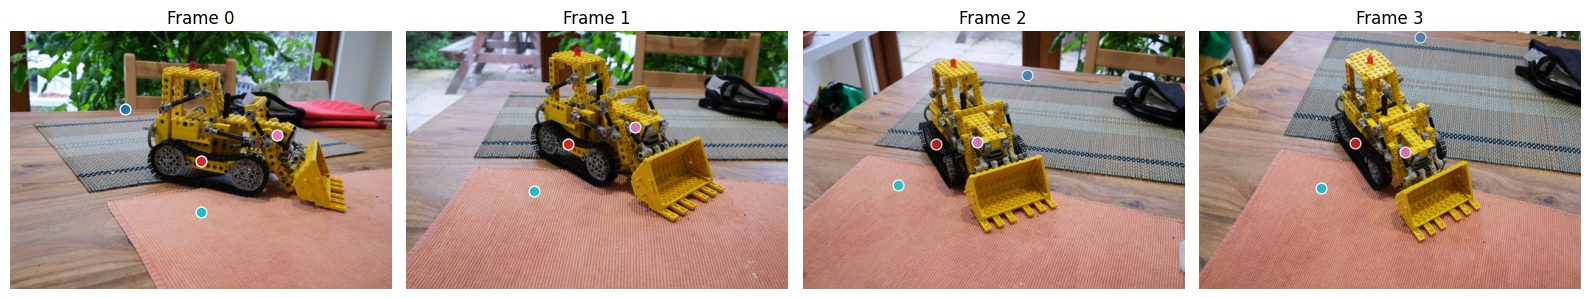

In [12]:
from PIL import Image as PILImage

imgs_np = to_np(images)  # (S, C, H, W), already normalized for the model
n_show = min(4, imgs_np.shape[0])
colors = plt.get_cmap('tab10')(np.linspace(0, 1, tracks.shape[1]))

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
axes = axes if n_show > 1 else [axes]
for i in range(n_show):
    img = imgs_np[i].transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    for k in range(tracks.shape[1]):
        x, y = tracks[i, k]
        alpha = float(np.clip(vis_np[i, k], 0.2, 1.0))
        axes[i].scatter([x], [y], color=colors[k], s=60, edgecolors='white', alpha=alpha)
    axes[i].set_title(f'Frame {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## Step 9. Interactive 3D visualization (point cloud + camera trajectory)

We use the depth+camera unprojection (`point_map_by_unprojection`), which the authors note is usually more accurate than the direct point-map branch, filtered by the depth confidence. Rendered inline with Plotly so it works headlessly on Colab.


In [13]:
import plotly.graph_objects as go

pts = point_map_by_unprojection.reshape(depth_np.shape[0], -1, 3) if point_map_by_unprojection.ndim == 3 else point_map_by_unprojection
pts_np = pts if isinstance(pts, np.ndarray) else to_np(pts)
pts_np = pts_np.reshape(depth_np.shape[0], -1, 3)

colors_rgb = imgs_np.transpose(0, 2, 3, 1).reshape(depth_np.shape[0], -1, 3)
colors_rgb = ((colors_rgb - colors_rgb.min()) / (colors_rgb.max() - colors_rgb.min()) * 255).astype(np.uint8)

conf_flat = dconf_np.reshape(depth_np.shape[0], -1)
conf_thr = np.quantile(conf_flat, 0.5)  # keep the more confident half of points

all_pts, all_colors = [], []
for i in range(depth_np.shape[0]):
    mask = conf_flat[i] > conf_thr
    all_pts.append(pts_np[i][mask])
    all_colors.append(colors_rgb[i][mask])
all_pts = np.concatenate(all_pts, axis=0)
all_colors = np.concatenate(all_colors, axis=0)

n_max = 60000
if len(all_pts) > n_max:
    idx = np.random.default_rng(0).choice(len(all_pts), n_max, replace=False)
    all_pts, all_colors = all_pts[idx], all_colors[idx]

color_strs = [f'rgb({r},{g},{b})' for r, g, b in all_colors]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=all_pts[:, 0], y=all_pts[:, 1], z=all_pts[:, 2],
    mode='markers', marker=dict(size=1.5, color=color_strs), name='point cloud'
))
fig.add_trace(go.Scatter3d(
    x=cam_centers[:, 0], y=cam_centers[:, 1], z=cam_centers[:, 2],
    mode='markers+lines+text',
    marker=dict(size=6, color='red'),
    line=dict(color='red', width=3),
    text=[f'cam{i}' for i in range(len(cam_centers))],
    name='camera trajectory'
))
fig.update_layout(
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=30),
    title='VGGT reconstruction: dense point cloud + recovered camera poses (single forward pass)'
)
fig.show()


## Step 10. Export the reconstruction (.ply)

Downloadable point cloud you can open in MeshLab / CloudCompare / Blender.


In [14]:
import trimesh

cloud = trimesh.PointCloud(vertices=all_pts, colors=all_colors)
out_path = '/content/vggt_reconstruction.ply'
cloud.export(out_path)
print(f"Saved point cloud to {out_path}")

from google.colab import files
files.download(out_path)


Saved point cloud to /content/vggt_reconstruction.ply


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>